In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

# Set up plotting style
plt.style.use('Solarize_Light2')
sns.set_theme(style="whitegrid")
sns.set_palette('husl')

# Lesson Logistic Regretion Part 1

## Finding Missing Data and how to Visualize the data.

In [3]:
 #1. Get the folder where your current notebook is saved
notebook_dir = Path.cwd()

# 2. Go up the folder tree to a shared folder (e.g., up 1 level)
# Use .parent to go up one level, or .parent.parent to go up two levels     
root_dir = notebook_dir.parent.parent

# 3. Build the path to the target folder and file
file_path_titanic_train = root_dir / "data" / "processed" / "titanic_train.csv"
train = pd.read_csv(file_path_titanic_train)
#print(df.columns.tolist())
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


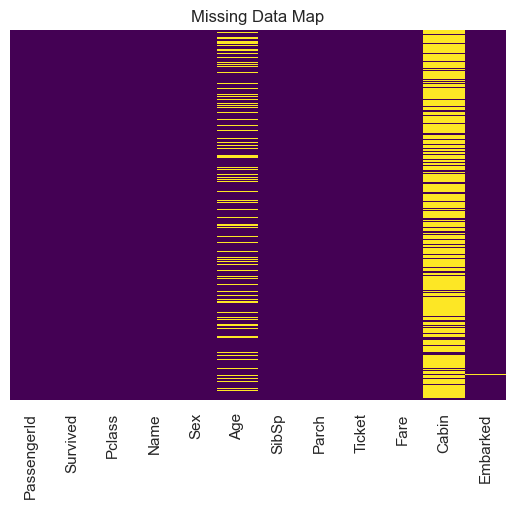

In [4]:

#This is a good way to show a hatmap for missing data on a DataFrame
# 1. Create the heatmap
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

# 2. Add a title
plt.title('Missing Data Map')
plt.show()
#train.isnull()

<Axes: xlabel='SibSp', ylabel='count'>

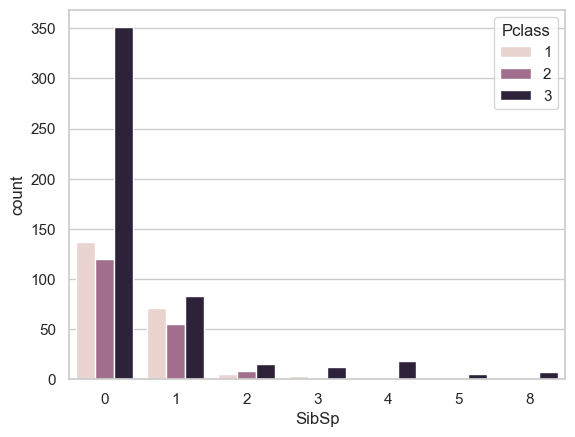

In [5]:
sns.countplot(x='SibSp',hue='Pclass',data=train)

<Axes: >

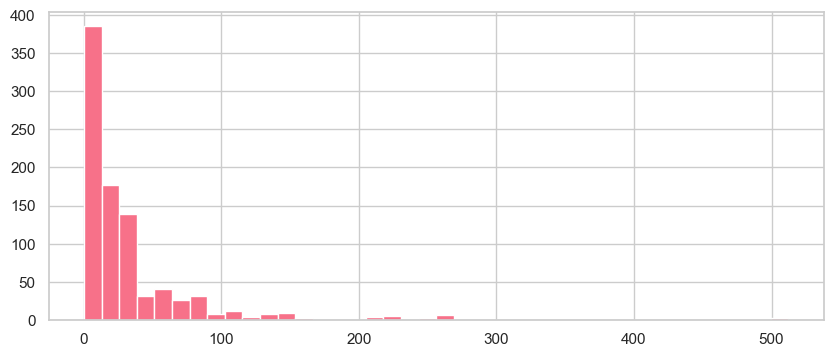

In [6]:
train['Fare'].hist(bins=40,figsize=(10,4))

## Use Plotly Express to make charts more interactive

In [7]:
fig = px.histogram(train, x="Fare", nbins=50)
fig.update_traces(marker={'color': 'magenta', 
                          'opacity': 0.5, 
                          'line': {'width':2, 'color':'cyan'}})
fig.show()

<Axes: xlabel='Age', ylabel='count'>

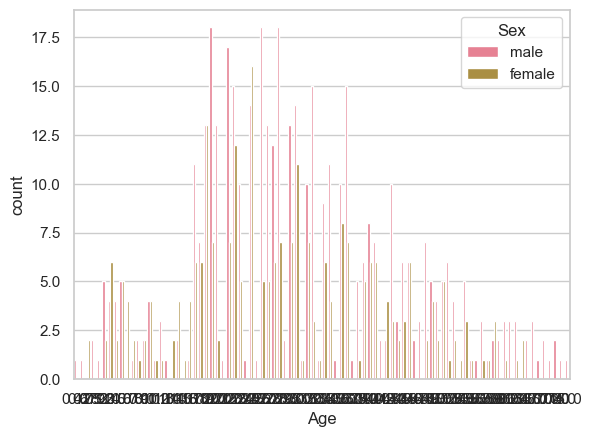

In [8]:
sns.countplot(x='Age',hue='Sex',data=train, legend='auto')

# Part 2 Replacing Missing Values 
- Imputation In technical fields, it refers to replacing missing data with estimated values

## in this part we worked on cleaning data, removing missing values creating dummy cols based
off COLS Sex Embbark and removed COLS we could not do anything with like Name & Ticket 

<Axes: xlabel='Pclass', ylabel='Age'>

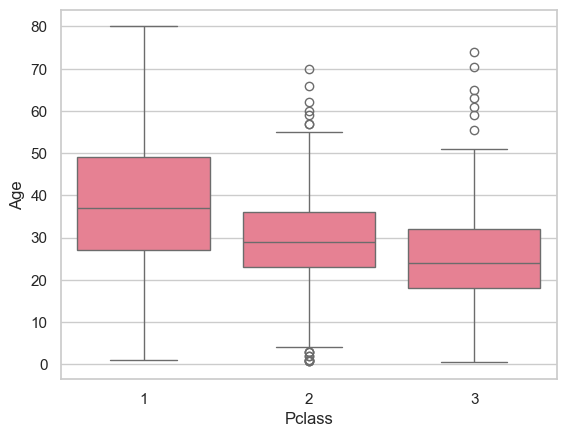

In [9]:
sns.boxplot(x='Pclass',y='Age',data=train)

In [10]:
def imput_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1] #Pclass = Passanger Class 

    if pd.isnull(Age):

        if Pclass == 1: # Frist Class
            return 37 # this is just a gesta- mate based on the mean of the age
        elif Pclass == 2: # Second Class
            return 28 
        else:
            return 24 # Else return Age if null for both Pclass 1 and 2 
    else:
        return Age



In [11]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
train['Age'] = train[['Age','Pclass']].apply(imput_age,axis=1) 

#Axis 0: I want the sum/mean of the whole column.
#Axis 1: I want to do math between different columns in the same row.


In [13]:
# As the Cabin columb contains too many unknowns and we can use any other data to convert to 0's 0r 1's
# we can drop the Cabin col 
train.drop('Cabin',axis=1,inplace=True) 

In [14]:
#Check to see if the Cabin Col is drpoed 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


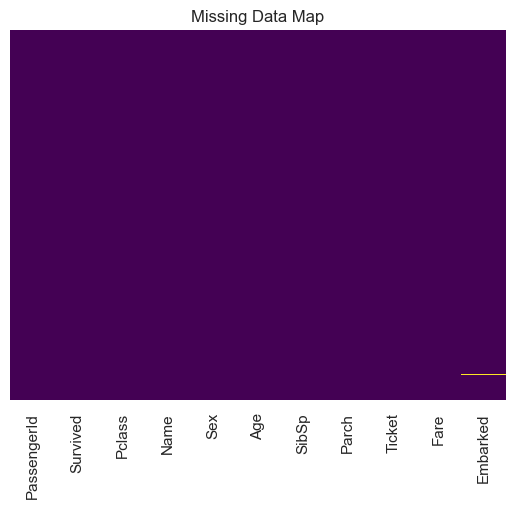

In [15]:
#This is a good way to show a hatmap for missing data on a DataFrame
# 1. Create the heatmap
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

# 2. Add a title
plt.title('Missing Data Map')
plt.show()
#train.isnull()

In [16]:
#From the heat map we can see that the Embarcked has one missing data se we can just themove the rest of the nan's 
train.dropna(inplace=True)

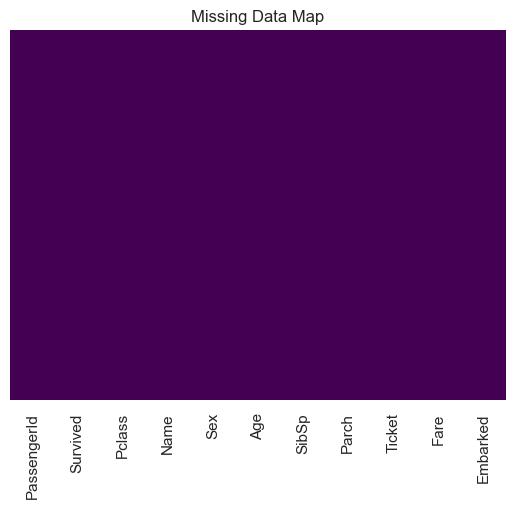

In [17]:
#This is a good way to show a hatmap for missing data on a DataFrame
# 1. Create the heatmap
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

# 2. Add a title
plt.title('Missing Data Map')
plt.show()
#train.isnull()

## We use pd.get_dummies because Machine Learning models cannot "read" text.

# One-Hot Encoding
 - Imagine your "Sex" column has two values: male and female. pd.get_dummies creates new columns      for each category.
 - &#9888; The "Dummy Variable Trap"
* Including both columns can confuse some mathematical models (like Linear Regression). To fix this, we usually use the drop_first=True argument:

Why not just use 1, 2, and 3?
You might wonder: "Why not just label 1st Class as 1, 2nd as 2, and 3rd as 3?"
Ordinal Data: For Class (1, 2, 3), numbers work because there is an order (1st is "better" than 3rd).
Nominal Data: For "Embarked" (C = Cherbourg, Q = Queenstown, S = Southampton), there is no "rank." If you used 1, 2, and 3, the computer might think Southampton (3) is "three times more important" than Cherbourg (1). Dummies prevent this bias.

- if you don't drop the first columb this would be multi-collinearity and will mess up the algorythim 


In [18]:
# Convert Sex and Embarked into dummy variables
sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train['Embarked'], drop_first=True)

# Add the new columns and drop the old text columns
train = pd.concat([train, sex, embark], axis=1)
train.drop(['Sex', 'Embarked', 'Name','Ticket'], axis=1, inplace=True)

In [19]:
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [20]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [21]:
train.drop('PassengerId',axis=1,inplace=True)

# Part 3 Logistic Regression 

## In this section We are actuall going to train and use the model to predict weather or not a Passanger surviced or not on the Titanic. 

In [22]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Create our teaining data X & y 

In [23]:
from sklearn.model_selection import train_test_split


In [24]:
# 1. Define X (everything except the 'Survived' column)
# 2. Define y (only the 'Survived' column)
X = train.drop('Survived', axis=1)  #not using inplace=True so train is just removing in memory Survived
y = train['Survived']

# 3. Perform the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)



In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
logmodel = LogisticRegression(max_iter=1000)
y_train.tail()

576    1
840    0
338    1
524    0
865    1
Name: Survived, dtype: int64

In [27]:
logmodel.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
predictions = logmodel.predict(X_test)

### SCIKIT Learn Classification report will tell you your precision your recall value is accurate
## forighn score etc..

- This way we don't have to read from a confusuin matrix 

In [29]:
from sklearn.metrics import classification_report

In [30]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       163
           1       0.85      0.69      0.76       104

    accuracy                           0.83       267
   macro avg       0.84      0.81      0.82       267
weighted avg       0.83      0.83      0.83       267



## You can also use the SKLEARN metics and crate a confusion metrics 

- KAGGLE has some good ideas for the Titanic data. 

In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
confusion_matrix(y_test,predictions)

array([[150,  13],
       [ 32,  72]])